# High-dimensional Regression

```{contents}
:local:
:depth: 2
```

:::{admonition} Learning Objectives
:class: tip

- Construct and evaluate multiple linear regression models in high-dimensional settings with proper validation.
- Apply dimensionality reduction (e.g., PCA) and interpret explained variance and loadings; perform principal component regression and compare to baseline models.
- Explain the difference between PCA (unsupervised) and PLS (supervised) dimensionality reduction and compare their predictive performance as a function of the number of components.
- Interpret the PLS projection matrix in terms of `x_weights_` and `x_loadings_` and verify the result against `model.transform()`.
:::

In [1]:
# Setup — load the Dow process dataset and apply standard scaling.
# The data exploration and scaling steps are covered in Topic 2.4.
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
plt.style.use('../settings/plot_style.mplstyle')

df = pd.read_excel('data/impurity_dataset-training.xlsx')

def is_real_and_finite(x):
    if not np.isreal(x):
        return False
    elif not np.isfinite(x):
        return False
    else:
        return True

all_data = df[df.columns[1:]].values
numeric_map = df[df.columns[1:]].map(is_real_and_finite)
real_rows = numeric_map.all(axis=1).copy().values
X = np.array(all_data[real_rows, :-5], dtype='float')
y = np.array(all_data[real_rows, -3], dtype='float').reshape(-1, 1)
x_names = [str(x) for x in df.columns[1:41]]
y_name = str(df.columns[-3])

ss = StandardScaler()
X_scaled = ss.fit_transform(X)

## Multi-Linear Regression

We can recall the general form of a linear regression model:

$$
y_i = \sum_j w_j X_{ij} + \epsilon_i
$$

Previously, we created features (columns of $X$) by transforming the original 1-dimensional input. In this case, we already have columns of $X$ provided from the data, so we can directly fit the model to the high-dimensional data matrix:

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
linreg = LinearRegression()
linreg.fit(X_train, y_train)
print(f"Train R^2: {linreg.score(X_train, y_train):.3f}")

Train R^2: 0.716


We can also scale the features before regression. In general, this can improve the accuracy or numerical stability of the model, or occasionally decrease the accuracy. As noted previously, one common pitfall in feature scaling is "data leakage", where data from the test/validation set is used to scale the data. Sometimes, this has little effect, but in other cases it can have very significant effects. It is possible to use the `scikit-learn` "pipeline" functionality to create a leakage-safe model that can easily be combined with hyperparameter optimization and other `scikit-learn` workflows:

In [3]:
#leakage-safe scaling with scikit-learn
from sklearn.pipeline import make_pipeline

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
pipe = make_pipeline(StandardScaler(), LinearRegression())
pipe.fit(X_train, y_train)
r2_train = pipe.score(X_train, y_train)
print(f"Train R^2 (pipeline with scaling): {r2_train:.3f}")

Train R^2 (pipeline with scaling): 0.716


The `make_pipeline` function chains preprocessing and modeling steps into a single estimator that fits and predicts in the correct order. For example,
`pipe = make_pipeline(StandardScaler(), LinearRegression())`
creates a workflow that:

- **Fits scaling only on training data** when you call `pipe.fit(X_train, y_train)`, preventing leakage.
- **Applies the same scaling to new/test data** automatically inside `pipe.predict(X_test)`.
- **Plays nicely with cross-validation** (`cross_val_score`, `GridSearchCV`): the scaler is refit **inside each fold**. When tuning hyperparameters of a downstream model, use the step name with a double underscore, e.g. `{'ridge__alpha': [0.1, 1, 10]}` for `make_pipeline(StandardScaler(), Ridge())`.
- Lets you **access the final model** with `pipe[-1]` or `pipe.named_steps['linearregression']` to inspect coefficients, etc.

This pattern is the standard way to keep preprocessing and modeling coupled, avoid data leakage, and ensure reproducible evaluation. You can also use the approach to chain together different types of models or functions to create complex pipelines that act as a single estimator. 

We see that the $r^2$ score is 0.71, which is not terrible, but not great either. We also see that it is identical to the un-scaled model. This is because, for linear models, any linear scaling approach will just change the magnitude of the coefficients. It can improve numerical stability, especially if some features have very different magnitudes, but in general it should not affect the results. However, for non-linear models (e.g. KRR, neural networks) scaling can have a much more significant impact.

We cannot really visualize the model like we did for the 1-dimensional case, since we have 40-dimensional inputs. However, we can make a **parity plot** to visualize the performance:

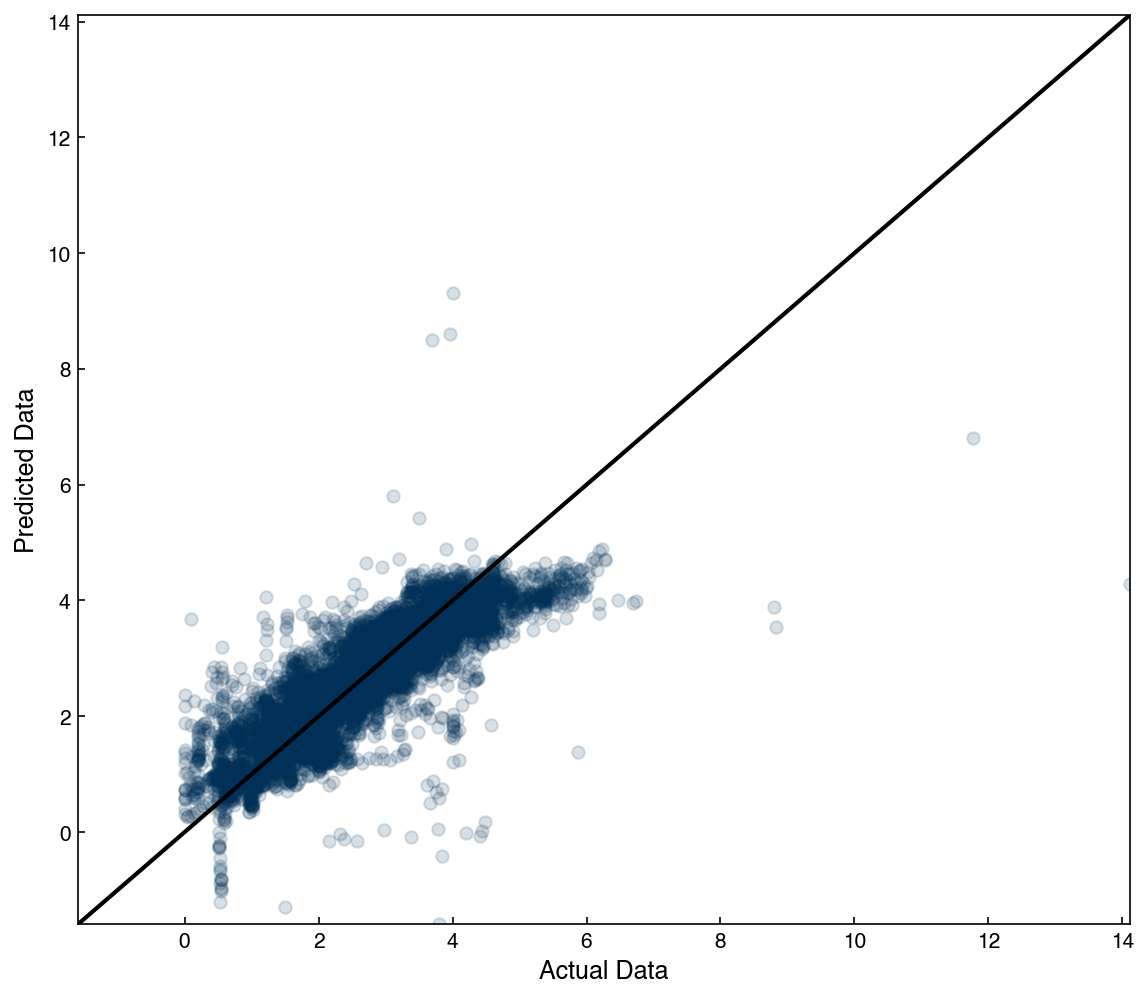

In [4]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))

yhat = pipe.predict(X)
y_true = y.ravel()
y_pred = yhat.ravel()
ax.scatter(y_true, y_pred, alpha=0.15)

# 45-degree reference line
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, '-k')
ax.set_xlim(lims); ax.set_ylim(lims)

ax.set_xlabel('Actual Data')
ax.set_ylabel('Predicted Data');

This looks reasonable, although there are quite a few outliers. We should also remember that we used hold-out here, so we can check the $r^2^ on the testing set to ensure there was no overfitting:

In [5]:
r2_test = pipe.score(X_test, y_test)

print(f"r^2 train = {r2_train:.3f}")
print(f"r^2 test  = {r2_test:.3f}")

r^2 train = 0.716
r^2 test  = 0.711


We see that they are comparable, which indicates that we have not over-fit. We can also visualize both training and testing errors with a parity plot:

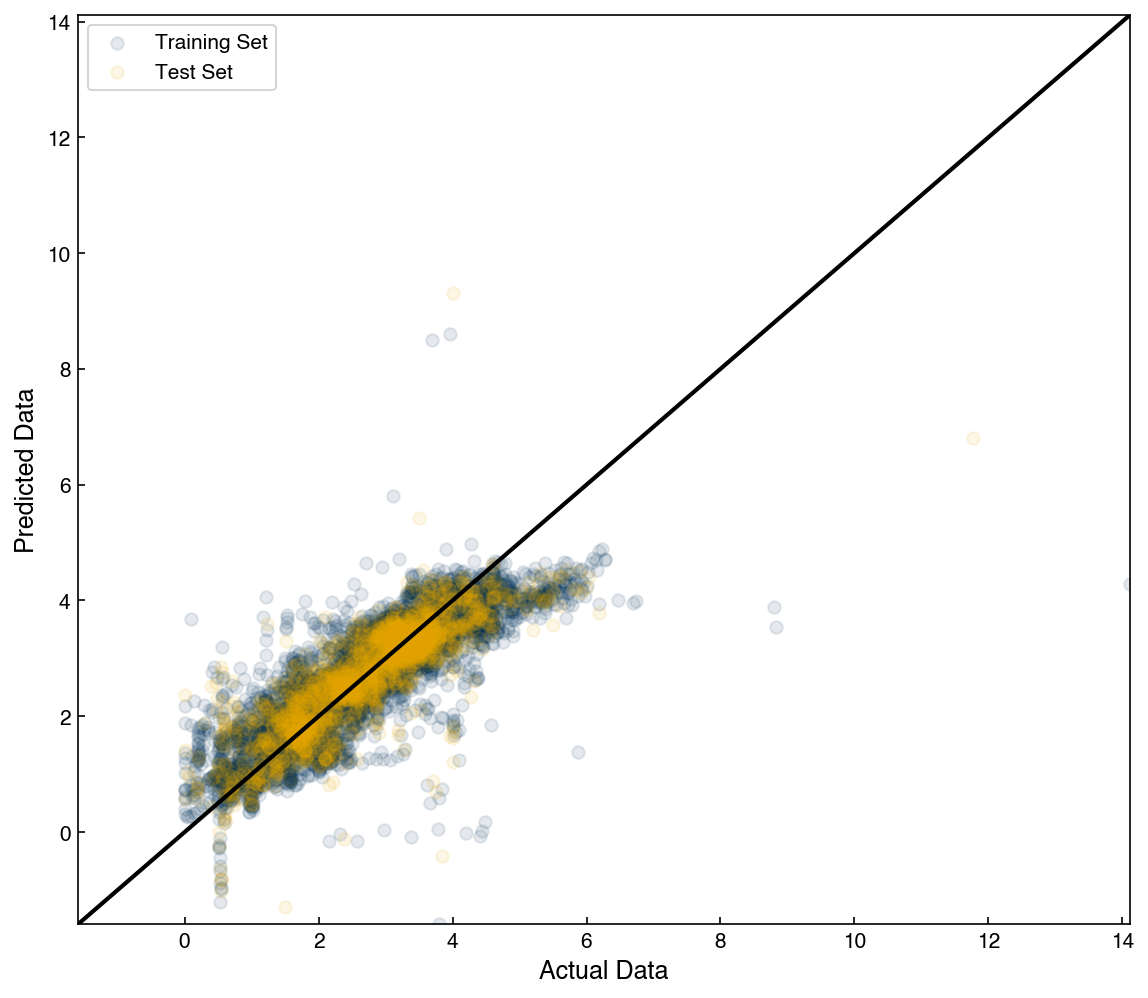

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))

yhat_train = pipe.predict(X_train).ravel()
yhat_test = pipe.predict(X_test).ravel()
ax.scatter(y_train.ravel(), yhat_train, alpha=0.10, label='Training Set')
ax.scatter(y_test.ravel(),  yhat_test,  alpha=0.10, label='Test Set')

# 45-degree reference line common to both
all_true = np.concatenate([y_train.ravel(), y_test.ravel()])
all_pred = np.concatenate([yhat_train, yhat_test])
lims = [min(all_true.min(), all_pred.min()), max(all_true.max(), all_pred.max())]
ax.plot(lims, lims, '-k')
ax.set_xlim(lims); ax.set_ylim(lims)

ax.set_xlabel('Actual Data')
ax.set_ylabel('Predicted Data')
ax.legend();

We can see that these look comparable, which confirms that we have not over-fit the model. It is always a good idea to check the parity plot to see if any patterns stand out!

This basic linear regression model is simple, but by testing it we now have a **baseline model**. This tells us that if we have any results worse than this we have a really bad model!

```{note}
**What is a “baseline model,” and why use one?**  
A baseline is the **simplest reasonable model** you can implement quickly and evaluate fairly. It establishes a **reference performance** so you can tell whether more complex methods add real value. A good baseline is:

- **Simple/fast** and easy to explain (e.g., `make_pipeline(StandardScaler(), LinearRegression())`).
- **Evaluated fairly** with proper splitting/CV, the same metrics, and fixed randomness.
- **Reproducible** with recorded settings and code.

If a new approach cannot **beat the baseline on held-out data**, revisit your data, features, or evaluation before adding complexity.
```

We see that the performance of the model is not great, and to improve things we will need to add some non-linearity. In 1-dimensional space we achieved this by adding transforms of the features as new features. However, this is more challenging in a high-dimensional space since the number of features will scale with the number of dimensions.

```{note}
**How many features would result if third-order interactions were considered?**  

A simple estimate can be obtained by taking the cube of the number of features, which would be $40^3 = 64,000$, but this is a significant over-estimate since there will be redundant combinations. A more accurate estimate requires some combinatorics: If you include **all degree-3 polynomial terms with replacement** (e.g., $x_i^3,\; x_i^2 x_j,\; x_i x_j x_k$), the count is $\binom{40 + 3 - 1}{3} = \binom{42}{3} = 11,480$, which is still larger than the number of data points we have.

This shows that the number of features grow **combinatorially** as the number of dimensions increases, and illustrates why naive feature expansion becomes impractical in high dimensions.
```

Kernel-based methods are very commonly used for high-dimensional spaces because they account for non-linear interactions, but the number of features does not exceed the number of data points. In your homework you will explore the application of KRR to this dataset.


:::{exercise}
:label: ex-reg-raw-vs-scale

Compare linear regression on the **original** features and on **rescaled** features.

1. Split the raw data with `train_test_split(X, y, test_size=0.3, random_state=0)`.
2. Fit `LinearRegression()` on the **raw** training features; record train/test $r^2$.
3. Fit a pipeline `make_pipeline(StandardScaler(), LinearRegression())` on the **same** split; record train/test $r^2$.
4. Show that the **predictions are (nearly) identical** on the test set by printing the max absolute difference between the two prediction vectors and the absolute difference in test $r^2$.
5. Compare the **coefficients**: print the top-10 by absolute value for (a) the raw model and (b) the scaled model. *(Optional)* Recover coefficients on the **raw scale** from the pipeline (using the scaler’s `mean_` and `scale_`) and verify they match the raw model’s coefficients.

:::

## Dimensionality Reduction

An alternative approach to creating high-dimensional models is to reduce the dimensionality. We will briefly look at some techniques here, and revisit this idea later in the course.

### Forward Selection

A very intuitive way to reduce dimensions is to just select a subset of the original features. The simplest strategy to select or rank features is to try them one-by-one, and keep the best feature at each iteration:

In [7]:
import numpy as np
from sklearn.linear_model import LinearRegression

N_features = 40
X_subset = X_scaled.copy()
x_names_subset = np.array(x_names, dtype=object).copy()
new_X = []
new_X_names = []

while len(new_X) < N_features and X_subset.shape[1] > 0:
    r2_list = []
    for j in range(X_subset.shape[1]):
        model = LinearRegression()  # create a linear regression model instance
        xj = X_subset[:, j].reshape(-1, 1)
        model.fit(xj, y)            # fit the model
        r2 = model.score(xj, y)     # r^2 for this single feature
        r2_list.append((r2, j))
    # select highest r^2 value
    r2_list.sort(key=lambda t: t[0])
    r2_max, j_max = r2_list[-1]
    new_X.append(X_subset[:, j_max].copy())
    new_X_names.append(x_names_subset[j_max])
    # remove selected feature from the pool
    x_names_subset = np.delete(x_names_subset, j_max)
    X_subset = np.delete(X_subset, j_max, axis=1)

print('The {} most linearly correlated features are:'.format(len(new_X)))
print(new_X_names)

new_X = np.array(new_X).T  # shape: (n_samples, k)

The 40 most linearly correlated features are:
['x10:Primary Column Bed1 DP', 'x5:Primary Column Feed Flow from Feed Column', 'x11:Primary Column Bed2 DP', 'x6:Primary Column Make Flow', 'x13:Primary Column Bed4 DP', 'x40: Feed Column Tails Flow', 'x24: Secondary Column Tails Flow', 'x1:Primary Column Reflux Flow', 'x12:Primary Column Bed3 DP', 'x4:Input to Primary Column Bed 2 Flow', 'x37: Feed Column Tails Flow to Primary Column', 'x21:Primary Column Bed 1 Temperature', 'x3:Input to Primary Column Bed 3 Flow', 'x26: Secondary Column Head Pressure', 'x20:Primary Column Bed 2 Temperature', 'x31: Secondary Column Bed 2 Temperature', 'x27: Secondary Column Base Pressure', 'x14:Primary Column Base Pressure', 'x7:Primary Column Base Level', 'x19:Primary Column Bed 3 Temperature', 'x9:Primary Column Condenser Reflux Drum Level', 'x39: Feed Column Steam Flow', 'x18:Primary Column Bed 4 Temperature', 'x36: Feed Column Recycle Flow', 'x2:Primary Column Tails Flow', 'x34: Secondary Column Tails 

```{note}
**About this "forward selection" loop**  
This implementation performs **univariate ranking** (pick best single feature, then the next best single feature, etc.). A full **forward stepwise** method would re-fit a multi-feature model at each step using the features already chosen **plus** each candidate feature, selecting the one that improves the model the most. We use the simpler ranking here for speed and clarity.
```

We can see how the $r^2$ score changes with the reduced features:

In [8]:
model = LinearRegression()  # create a linear regression model instance
model.fit(new_X, y)         # fit the model on the selected features
r2 = model.score(new_X, y)  # r^2 on the same data
print("r^2 = {}".format(r2))

r^2 = 0.7168241690081087


We see that with just 4 features the model performance is substantially reduced. We can keep increasing the number until it is comparable to the full model.

```{note}
Below we compute $r^2$ as we include more ranked features and identify the **minimum** number of features needed to reach $r^2\ge 0.60$.
```

Minimum k achieving r^2 ≥ 0.6: 17 (r^2 = 0.622)


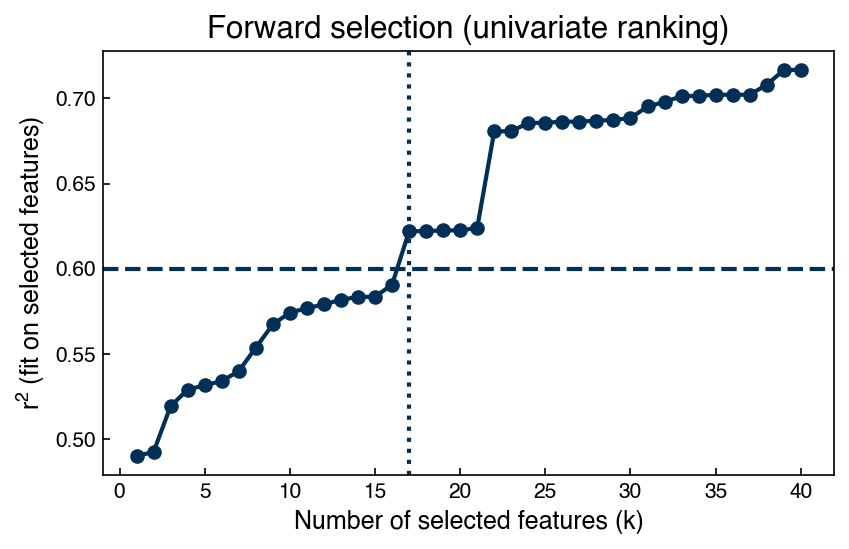

In [9]:
k_max = new_X.shape[1]
r2_path = []
ks = np.arange(1, k_max + 1)

for k in ks:
    Xk = new_X[:, :k]
    model = LinearRegression().fit(Xk, y)
    r2_path.append(model.score(Xk, y))

r2_path = np.array(r2_path)
# first k reaching target (if any)
target = 0.60
hit = np.argmax(r2_path >= target) if np.any(r2_path >= target) else None

plt.figure(figsize=(6,4))
plt.plot(ks, r2_path, 'o-')
plt.axhline(target, linestyle='--')
if hit is not None and r2_path[hit] >= target:
    plt.axvline(ks[hit], linestyle=':')
plt.xlabel('Number of selected features (k)')
plt.ylabel('$r^2$ (fit on selected features)')
plt.title('Forward selection (univariate ranking)')
plt.tight_layout()

if hit is not None and r2_path[hit] >= target:
    print(f"Minimum k achieving r^2 ≥ {target}: {ks[hit]} (r^2 = {r2_path[hit]:.3f})")
else:
    print(f"Target r^2 ≥ {target} not reached with up to {k_max} features.")

Be careful, since just because features are not *linearly* correlated does not mean that they are not *non-linearly* correlated (in other words, we might reject a feature that is actually very descriptive, if that description is highly non-linear) . There is also no guarantee that we are not finding correlated features, since if one feature has a high correlation with the output, and is also correlated with another feature, then that feature will also be correlated with the output. More advanced forward selection strategies can be used to reduce this, as shown with a standard implementation below:

**Standard scikit-learn (full forward stepwise) feature selection**

In [10]:
# Full forward stepwise selection using scikit-learn's SequentialFeatureSelector (SFS)
from sklearn.feature_selection import SequentialFeatureSelector

est = make_pipeline(StandardScaler(), LinearRegression())

# Choose how many features to keep (example: 10) and use forward stepwise with cross-validation
sfs = SequentialFeatureSelector(
    est, n_features_to_select=10, direction="forward",
    scoring="r2", cv=5, n_jobs=-1
).fit(X, y.ravel())

selected_idx = sfs.get_support(indices=True)
selected_names = [x_names[i] for i in selected_idx]

print("Selected feature indices:", selected_idx)
print("Selected feature names:", selected_names)

# Transform X to the selected subset and fit a final model on the whole dataset
X_fs = sfs.transform(X)
final_model = LinearRegression().fit(X_fs, y)
print("r^2 on full data using selected subset:", final_model.score(X_fs, y))

Selected feature indices: [ 8  9 15 16 23 24 28 32 34 36]
Selected feature names: ['x9:Primary Column Condenser Reflux Drum Level', 'x10:Primary Column Bed1 DP', 'x16:Primary Column Tails Temperature', 'x17:Primary Column Tails Temperature 1', 'x24: Secondary Column Tails Flow', 'x25: Secondary Column Tray DP', 'x29: Secondary Column Tray 3 Temperature', 'x33: Secondary Column Tray 1 Temperature', 'x35: Secondary Column Tails Concentration', 'x37: Feed Column Tails Flow to Primary Column']
r^2 on full data using selected subset: 0.6055868410819657


Note that the features selected with this more sophisticated approach differ from the naive approach, and that we are able to reach $r^2 > 0.6$ with just 10 features, instead of the 17 required above. This is because many of the features are highly correlated (as we already saw with the correlation matrix above), so some of the features selected in the naive univariate ranking were partially redundant. The `SequentialFeatureSelector` approach above is much less transparent, and uses some more advanced `scikit-learn` features, but it also yields good results with relatively little code. Don't worry if you don't understand all the details: the main point is that there are different ways to do feature selection, and each strategy can yield different results.

```{note}
**Choosing `n_features_to_select`**  
`SequentialFeatureSelector` requires you to specify how many features to keep. In practice you can sweep over `k` (e.g., 1–20) and pick the smallest `k` that reaches a target cross-validated score, or use a validation curve to balance performance and parsimony.
```

### Principal component analysis

An alternative strategy to avoid having correlated features is to ensure that features are orthogonal using the eigenvectors of the covariance matrix. The code below finds the eigenvectors of the covariance matrix, which we know will be orthogonal (from the "linear algebra" module).

In [11]:
import numpy as np

# Use the (standardized) covariance matrix for PCA
cov = np.cov(X_scaled.T)

# For symmetric matrices (covariance), use eigh (guaranteed real eigenvalues)
vals, vecs = np.linalg.eigh(cov)  # vals ascending
# sort descending by variance explained
idx = np.argsort(vals)[::-1]
PCvals = vals[idx]
PCvecs = vecs[:, idx]

# sanity checks: orthonormal eigenvectors
print('dot(PC1, PC1) =', float(np.dot(PCvecs[:, 0], PCvecs[:, 0])))
print('dot(PC1, PC2) =', float(np.dot(PCvecs[:, 0], PCvecs[:, 1])))

dot(PC1, PC1) = 0.9999999999999992
dot(PC1, PC2) = 2.0827687919277988e-16


These eigenvectors are orthogonal, and represent a linear transformation of the original features into an orthogonal space, which removes feature correlation. It turns out that by taking the eigenvalues of the covariance matrix you are actually doing something called **principal mponent analysis**, which is a classic dimensionality reduction technique. The eigenvectors of the covariance matrix identify the "natural" coordinate system of the data. We can visualize this with some toy data in two dimensions (note that the script to generate this file is available in "settings"):

```{figure} images/pca_illustration.png
:width: 800px
:align: center

Toy data in original 2-dimensional coordinates (left) and in rotated "principal component vector" coordinates (right).
```

```{note}
**PCA coordinates vs. Cartesian coordinates**  
Think of the usual x–y axes as a fixed Cartesian frame. PCA rotates this frame to a new set of perpendicular axes (the principal components) that align with the directions of greatest variance in the data—similar to choosing an origin and x- and y-axis when solving an engineering problem. The new axes are orthonormal (like the unit vectors i, j, k), and projecting data onto them is just taking dot products with these unit vectors. In this rotated frame, covariances vanish (the off-diagonals go to ~0), so variability is concentrated along a few axes, making analysis and modeling simpler, but the underlying data is not really changed.
```

The eigenvalues provide the variance in each direction, and we can use this to determine how much variance each principal component contributes:

Total variance (trace of covariance): 40.00388500388501
First 5 explained variance ratios: [0.5851 0.1046 0.0583 0.0441 0.0341]
Components needed for ≥90% variance: 8


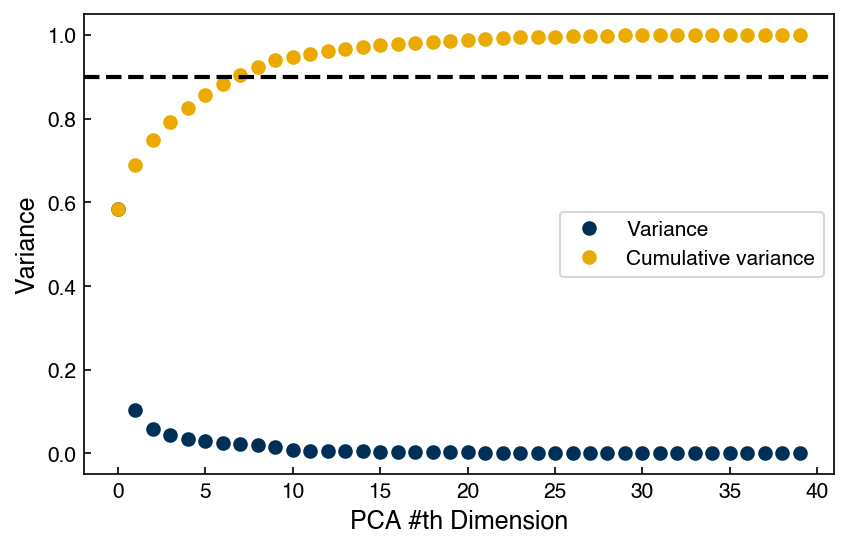

In [12]:
import numpy as np
import matplotlib.pyplot as plt

total_variance = np.sum(PCvals)
explained_variance = PCvals / total_variance  # already sorted desc

print('Total variance (trace of covariance):', float(total_variance))
print('First 5 explained variance ratios:', np.round(explained_variance[:5], 4))

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(explained_variance, 'o', label='Variance')
ax.plot(np.cumsum(explained_variance), 'o', label='Cumulative variance')
ax.axhline(0.9, linestyle='--', color='k')
ax.set_xlabel('PCA #th Dimension')
ax.set_ylabel('Variance')
ax.legend(loc='best');

# Report how many components capture 90% variance
k90 = np.searchsorted(np.cumsum(explained_variance), 0.9) + 1
print(f"Components needed for ≥90% variance: {k90}")

We can use this to say how many principal components are needed to capture a specified fraction of the variance (e.g., 90%).

Finally, we can "project" the data onto the principal components. This is equivalent to re-defining the axes of the data. If we take the covariance of this rotated data, we will see that all of the features are now uncorrelated:

Projection shape: (10297, 40)


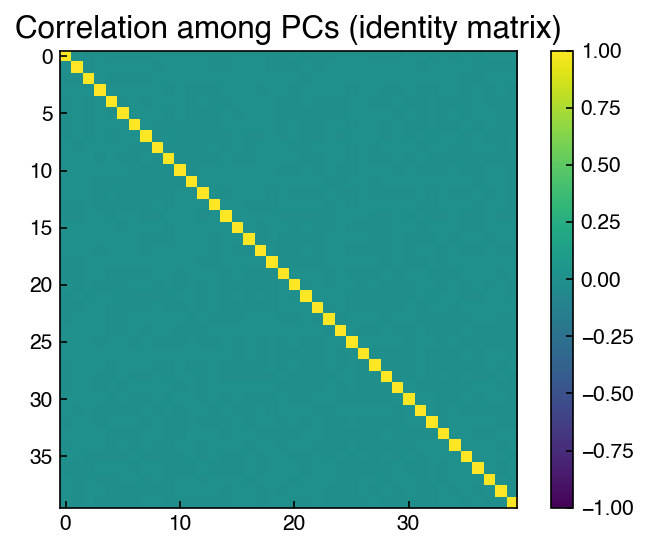

In [13]:
PC_projection = np.dot(X_scaled, PCvecs)
print('Projection shape:', PC_projection.shape)

corr_PCs = np.corrcoef(PC_projection.T)
fig, ax = plt.subplots(figsize=(5,4))
c = ax.imshow(corr_PCs, vmin=-1, vmax=1)
fig.colorbar(c);
ax.set_title('Correlation among PCs (identity matrix)');

After projection, we still have 40 features but they are now orthogonal - there is no covariance! This means that each one contains unique information.


We will talk a lot more about PCA throughout the course, but for now you should know:

- Principal component vectors are obtained from the eigenvectors of the covariance matrix
- Principal components are orthogonal
- Principal components explain the variance in multi-dimensional data
- Data can be projected onto principal components


:::{exercise}
:label: ex-reg-pca-verify

Using `sklearn.decomposition.PCA`, verify that scikit-learn's results match the manual PCA above.

1. Fit `PCA()` on `X_scaled`. Inspect the key attributes: `n_components_`, `components_` (principal axes), `explained_variance_`, `explained_variance_ratio_`, `singular_values_`, and `mean_`.
2. Compare `explained_variance_` with the eigenvalues you computed above (`PCvals`). They should match (within numerical tolerance).
3. Compare principal axes: `components_.T` should equal `PCvecs` **up to sign**. (Hint: compute `R = PCvecs.T @ components_.T` and use `np.sign(np.diag(R))` to align signs.)
4. Compare scores/projections: `pca.transform(X_scaled)` should match your `PC_projection` **up to the same signs**.
5. Plot the explained variance ratio and its cumulative sum; confirm it matches the manual curves.

:::


## Principal Component Regression

We can also use the projected data as inputs to a regression model. This is called **principal component regression** (PCR):

In [14]:
from sklearn.linear_model import LinearRegression

# Use the PCA projection computed earlier in this topic (PC_projection)
model = LinearRegression()  # create a linear regression model instance
model.fit(PC_projection, y)  # fit the model
r2 = model.score(PC_projection, y)  # r^2 on the same data
print(f"r^2 = {r2:.3f}")

r^2 = 0.717


Let's compare this to the original data:

In [15]:
model = LinearRegression()  # create a linear regression model instance
model.fit(X_scaled, y)      # fit the model on scaled original features
r2 = model.score(X_scaled, y)
print(f"r^2 = {r2:.3f}")

r^2 = 0.717


We see that the answer is the same. This is because we are still ultimately including all the same information. However, if we want to reduce the number of features we will see a difference:

In [16]:
N = 8

model_PC = LinearRegression()
model_PC.fit(PC_projection[:, :N], y)
r2 = model_PC.score(PC_projection[:, :N], y)
print(f"r^2 PCA = {r2:.3f}")

model = LinearRegression()
model.fit(X_scaled[:, :N], y)
r2 = model.score(X_scaled[:, :N], y)
print(f"r^2 regular = {r2:.3f}")

r^2 PCA = 0.581
r^2 regular = 0.476


```{note}
**Why is a PCR model not always better than direct linear regression?**  
PCA orders directions by **variance in X**, not by how well they **predict y**. A high-variance component can be weakly related (or unrelated) to the target, while a lower-variance component might carry most of the predictive signal. PCR is unsupervised in its dimensionality reduction; it ignores `y` when choosing components.
```

The PCA projection collects as much information as possible in each feature and orders components by variance. We can also check them one-by-one to see how they correlate:

In [17]:
score_list = []
for j in range(PC_projection.shape[1]):
    model = LinearRegression()
    xj = PC_projection[:, j].reshape(-1, 1)
    model.fit(xj, y)
    r2 = model.score(xj, y)
    score_list.append((r2, j))

score_list.sort(reverse=True)
for r2j, j in score_list:
    print(f"PC{j:02d} : r^2 = {r2j:.3f}")

PC01 : r^2 = 0.207
PC00 : r^2 = 0.174
PC06 : r^2 = 0.061
PC07 : r^2 = 0.060
PC04 : r^2 = 0.044
PC25 : r^2 = 0.017
PC08 : r^2 = 0.016
PC05 : r^2 = 0.014
PC02 : r^2 = 0.013
PC16 : r^2 = 0.013
PC33 : r^2 = 0.012
PC18 : r^2 = 0.009
PC09 : r^2 = 0.009
PC15 : r^2 = 0.008
PC03 : r^2 = 0.007
PC21 : r^2 = 0.007
PC31 : r^2 = 0.006
PC22 : r^2 = 0.005
PC14 : r^2 = 0.004
PC11 : r^2 = 0.003
PC39 : r^2 = 0.003
PC38 : r^2 = 0.003
PC10 : r^2 = 0.002
PC27 : r^2 = 0.002
PC32 : r^2 = 0.002
PC13 : r^2 = 0.002
PC37 : r^2 = 0.002
PC20 : r^2 = 0.002
PC28 : r^2 = 0.001
PC12 : r^2 = 0.001
PC36 : r^2 = 0.001
PC34 : r^2 = 0.001
PC24 : r^2 = 0.001
PC26 : r^2 = 0.001
PC17 : r^2 = 0.000
PC35 : r^2 = 0.000
PC30 : r^2 = 0.000
PC19 : r^2 = 0.000
PC29 : r^2 = 0.000
PC23 : r^2 = 0.000


We see that the second principal component is actually the best, the first is the second best, and the seventh is third best. This is because the principal components only use variance of the inputs, which may or may not correlate to the outputs.&#x20;

It is common to use PCA or other dimensionality reduction techniques prior to regression when working with high-dimensional data. It is often possible to construct models that have better performance with fewer input dimensions, especially when working with non-linear models. However, it is important to note that **each principal component feature is a linear combination of _all_ input features.** In other words, you still need to use all of the features to construct a PCR model. If you are trying to reduce the information that goes into the model (instead of just the dimensionality of the model), then it is necessary to use feature selection techniques instead of or in addition to principal component analysis.

### Partial Least Squares (PLS)

Unlike PCA—which is **unsupervised** and finds directions of maximum variance in **X**—Partial Least Squares is **supervised**: it finds latent components that maximize the **covariance between X and y**. As a result, PLS components are chosen to be predictive of the target. PLS is especially helpful when there are many collinear features and relatively few samples. We will return to PLS and supervised dimensionality reduction later in the course, but it is useful to contrast it with principal component regression.

In [18]:
# PLS via scikit-learn (with scaling and a held-out test split)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Choose number of latent components (tune this via CV in practice)
pls_k = 8
pipe_pls = make_pipeline(StandardScaler(), PLSRegression(n_components=pls_k))
pipe_pls.fit(X_train, y_train.ravel())
print(f"PLS (k={pls_k}) train r^2: {pipe_pls.score(X_train, y_train):.3f}")
print(f"PLS (k={pls_k})  test r^2: {pipe_pls.score(X_test,  y_test):.3f}")

PLS (k=8) train r^2: 0.672
PLS (k=8)  test r^2: 0.701


If we compare the $r^2$ for PLS with 8 components, we see that it is higher than the $r^2$ for PCR with the same number of features. It is also higher than the $r^2$ for regular multi-linear regression with 10 features selected from forward selection. The PLS approach will generally give the highest $r^2$ score of any linear model as a function of the number of features, since the features are directly constructed to maximize the correlation. However, similar to PCR, it does require all of the original features as an input, so it may be less practical than feature selection in some cases (e.g. one of the features is very hard or expensive to measure or compute).

```{note}
**Tuning PLS components**
It is possible to use cross-validation to select `n_components`. With a pipeline, you can use `GridSearchCV` and the step name `plsregression__n_components`, e.g. `{'plsregression__n_components': range(1, min(20, X.shape[1]) + 1)}`.
```

#### Understanding the PLS Projection Matrix

Under the hood, `PLSRegression` computes two sets of weights at each latent component: the **X-weights** ($W$, `x_weights_`) and the **X-loadings** ($P$, `x_loadings_`). These capture different aspects of how the original features relate to the latent components.

- **X-weights** $W$: the directions in the original feature space that maximize covariance with $y$. These are the raw coefficients used to form each latent score from the *deflated* $X$ matrix at each iteration.
- **X-loadings** $P$: how much of the original $X$ is explained by each latent score after it is computed. They describe the back-projection from score space to the original feature space.

Because the deflation step modifies $X$ at each iteration, the weight vectors are not exactly orthogonal in the original feature space. The actual projection matrix that maps $X$ directly to the latent scores (without iterative deflation) is:

$$W^* = W (P^\top W)^{-1}$$

and in scikit-learn notation: `W_star = model.x_weights_ @ np.linalg.inv(model.x_loadings_.T @ model.x_weights_)`.

This is also accessible via `model.x_rotations_`. We can verify that applying this matrix manually gives the same scores as `model.transform(X)`:

In [19]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

pls_k = 8
pls = PLSRegression(n_components=pls_k)
pls.fit(StandardScaler().fit_transform(X_train), y_train.ravel())

# Reconstruct the projection matrix from weights and loadings
W_star = pls.x_weights_ @ np.linalg.inv(pls.x_loadings_.T @ pls.x_weights_)
X_train_manual = StandardScaler().fit_transform(X_train) @ W_star
X_train_transform = pls.transform(StandardScaler().fit_transform(X_train))

max_diff = np.abs(X_train_manual - X_train_transform).max()
print(f'Max absolute difference (manual vs transform): {max_diff:.2e}')
print(f'x_rotations_ and W_star agree: {np.allclose(W_star, pls.x_rotations_, atol=1e-10)}')

Max absolute difference (manual vs transform): 1.84e-03
x_rotations_ and W_star agree: True


The numerical agreement confirms that `x_rotations_` encodes the full, non-iterative projection from $X$ to latent score space.

#### PCR vs. PLS: r² as a Function of Components

A useful diagnostic is to compare how quickly PCR and PLS accumulate predictive power as more latent components are added:

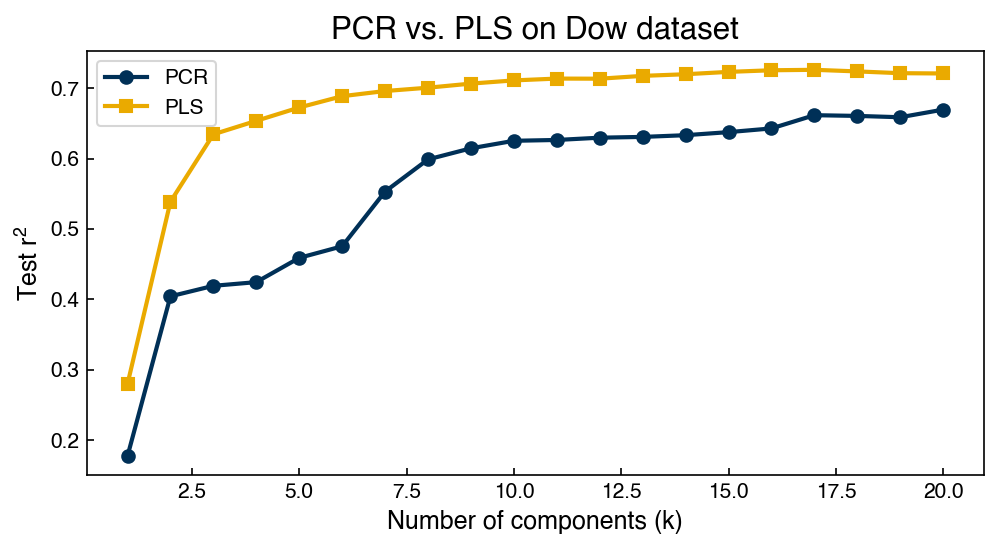

In [20]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

k_range = range(1, 21)
r2_pcr = []
r2_pls = []

for k in k_range:
    pipe_pcr = make_pipeline(StandardScaler(), PCA(n_components=k), LinearRegression())
    pipe_pcr.fit(X_train, y_train)
    r2_pcr.append(pipe_pcr.score(X_test, y_test))

    pipe_pls = make_pipeline(StandardScaler(), PLSRegression(n_components=k))
    pipe_pls.fit(X_train, y_train.ravel())
    r2_pls.append(pipe_pls.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), r2_pcr, 'o-', label='PCR')
ax.plot(list(k_range), r2_pls, 's-', label='PLS')
ax.set_xlabel('Number of components (k)')
ax.set_ylabel('Test $r^2$')
ax.set_title('PCR vs. PLS on Dow dataset')
ax.legend()
plt.tight_layout()

PLS consistently achieves higher test $r^2$ than PCR with the same number of components. This is because PLS explicitly uses $y$ when constructing each latent direction, whereas PCA orders components purely by variance in $X$ — some high-variance directions may be nearly orthogonal to the target.

The crossover behavior (PLS saturates earlier) is also typical: because PLS components are already chosen to be predictive, adding more components yields diminishing returns faster than PCR, where many early components may carry little signal about $y$.


:::{exercise}
:label: ex-reg-pcr-pls

Here you will use pipelines to compare some of the models above:

1. Split the data with `train_test_split(X, y, test_size=0.3, random_state=0)`.
2. Build three pipelines:
   - `pipe_lr = make_pipeline(StandardScaler(), LinearRegression())`
   - `pipe_pcr_k = make_pipeline(StandardScaler(), PCA(n_components=k), LinearRegression())`
   - `pipe_pls_k = make_pipeline(StandardScaler(), PLSRegression(n_components=k))`
3. Plot the $r^2$ score of PCR and PLS as a function of the number of components and show that PLS is always higher.
4. Show that when `k` is equal to the total number of features, the results are the same for all three models.
:::


## Summary

- **Multi-linear regression** with scikit-learn pipelines provides a reproducible, leakage-safe baseline ($r^2 \approx 0.71$ on the Dow dataset).
- **Forward selection** ranks features by univariate correlation; `SequentialFeatureSelector` performs true forward stepwise selection with cross-validation.
- **PCA** rotates data into orthogonal directions of maximum variance in **X**; **PCR** uses these components as regression features.
- **PLS** is supervised—it maximizes covariance between **X** and **y**—and typically achieves higher predictive accuracy than PCR with the same number of components.
- The PLS **projection matrix** $W^* = W(P^\top W)^{-1}$ maps the original features directly to latent scores; it is accessible via `model.x_rotations_` and can be verified by comparison with `model.transform(X)`.
- A PCR vs. PLS $r^2$ comparison plot shows that PLS saturates faster: its components are explicitly chosen to be predictive, whereas PCA components are ordered by variance in $X$ alone.

## Additional reading

- Hastie, Tibshirani, & Friedman (2009). *The Elements of Statistical Learning*, 2nd ed., Ch. 3 (Linear Methods for Regression).
- James, Witten, Hastie, & Tibshirani (2013). *An Introduction to Statistical Learning*, Ch. 6 (Linear Model Selection).
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Ch. 12.1 (PCA).